<a href="https://colab.research.google.com/github/joiepark/assignment_esaa/blob/main/YB%205.2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 평가



*   머신러닝은 데이터 가공/변환, 모델 학습/예측, 그리고 평가의 과정으로 구성된다. 머신러닝 모델은 여러 방법으로 그 예측 성능을 평가할 수 있다. **성능 평가 지표(Evaluation Metric)**는 일반적으로 모델이 분류냐, 회귀냐에 따라 여러 종류로 나뉜다. 회귀의 경우 대부분 실제값과 예측값의 오차 평균값에 기반한다. (e.g. 오차에 절댓값을 씌운 뒤 평균 오차를 구하는 방법, 오차의 제곱 값에 루트를 씌운 뒤 평균 오차를 구하는 방법) 분류의 평가방법도 일반적으로는 실제 결과 데이터와 예측 결과 데이터가 얼마나 정확하고 오류가 적게 발생하는가에 기반하지만, 단순히 이런 정확도만 가지고 판단했다가는 잘못된 평가 결과를 마주할 수 있다. 이 장에서는 분류에 사용되는 성능 평가 지표에 대해 알아본다. 특히, 0과 1로 결정값이 한정되는 이진 분류에서는 정확도보다는 다른 성능 평가 지표가 더 중요시되는 경우가 많다.
*   분류의 성능 평가 지표 - 정확도(Accuracy), 오차행렬(Confusion Matrix), 정밀도(Precision), 재현율(Recall), F1 스코어, ROC AUC
*   분류는 결정 클래스 값 종류의 유형에 따라 긍정/부정과 같은 2개의 결괏값만을 가지는 **이진 분류**와, 여러 개의 결정 클래스 값을 가지는 **멀티 분류**로 나눌 수 있다. 위에서 언급한 분류의 성능 평가 지표는 이진/멀티 분류 모두에 적용되는 지표이나, 특히 이진 분류에서 더욱 중요하게 강조하는 지표이다.

## 정확도(Accuracy)
*   정확도란 실제 데이터에서 예측 데이터가 얼마나 같은지를 판단하는 지표이다. (정확도) = (예측 결과가 동일한 데이터 건수)/(전체 예측 데이터 건수)
*   정확도는 직관적으로 모델 예측 성능을 나타내는 평가 지표이다. 하지만 이진 분류의 경우 데이터의 구성에 따라 ML 모델을 왜곡할 수 있기 때문에 정확도 수치 하나만 가지고 성능을 평가하지 않는다.
*   정확도 지표가 어떻게 ML 모델의 성능을 왜곡하는 것일까? 앞의 타이타닉 예제 수행 결과를 보면, ML 알고리즘을 적용한 후 예측 정확도의 결과가 보통 80%대였지만, 탑승객이 남자인 경우보다 여자인 경우에 생존 확률이 높았기 때문에 별다른 알고리즘의 적용 없이 무조건 성별이 여자인 경우 생존으로, 남자인 경우 사망으로 예측해도 이와 비슷한 수치가 나올 수 있다. 단지 성별 조건 하나만을 가지고 결정하는 별거 아닌 알고리즘도 높은 정확도를 나타내는 상황이 발생하는 것이다.





In [3]:
from sklearn.base import BaseEstimator
import numpy as np
## 사이킷런의 BaseEstimator 클래스를 상속받아 아무런 학습을 하지 않고 성별에 따라 생존자를 예측하는 단순한 Classifier를 생성한다

class MyDummyClassifier(BaseEstimator):
  ## fit() 메서드는 아무것도 학습하지 않는다
  def fit(self, X, y=None):
    pass
  ## predict() 메서드는 단순히 Sex 피처가 1이면 0, 그렇지 않으면 1로 예측한다
  def predict(self, X):
    pred = np.zeros((X.shape[0], 1))
    for i in range (X.shape[0]) :
      if X['Sex'].iloc[i] == 1 :
        pred[i] = 0
      else :
        pred[i] = 1

    return pred

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
## 생성된 MyDummyClassifier를 이용해 앞 장의 타이타닉 생존자 예측을 수행한다

## 원본 데이터를 재로딩 - 데이터 가공 - 학습 데이터/테스트 데이터 분할을 차례로 실시한다
titanic_df = pd.read_csv('/content/titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)
X_titanic_df = transform_features(X_titanic_df)
X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df,
                                                    test_size=0.2, random_state=0)

## 위에서 생성한 Dummy Classifier를 이용해 학습/예측/평가를 수행한다
myclf = MyDummyClassifier()
myclf.fit(X_train, y_train)

mypredictions = myclf.predict(X_test)
print('Dummy Classifier의 정확도는: {0:.4f}'.format(accuracy_score(y_test, mypredictions)))

Dummy Classifier의 정확도는: 0.2123


/tmp/ipykernel_847/3273476368.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_847/3273476368.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 



*   특히 정확도는 불균형한(imbalanced) 레이블 값 분포에서 ML 모델의 성능을 판단할 경우, 적합한 평가 지표가 아니다. (e.g. 100개의 데이터가 있고 이 중에 90개의 데이터 레이블이 0, 단 10개의 데이터 레이블이 1이라고 한다면 무조건 0으로 예측 결과를 반환하는 ML 모델의 경우라도 정확도가 90%가 된다.)
*   항목 추가



In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
## MNIST 데이터 세트를 변환해 불균형한 세트(전체 데이터의 10%만 True, 90%는 False)로 만든 뒤에 정확도 지표 적용 시 어떤 문제가 발생할 수 있는지 살펴보고자 한다

class MyFakeClassifier(BaseEstimator):
  def fit(self, X, y):
    pass

  ## 입력값으로 들어오는 X 데이터 세트의 크기만큼 모두 0값으로 만들어서 반환한다
  def predict(self, X):
    return np.zeros( (len(X), 1), dtype=bool)

## 사이킷런의 내장 데이터 세트인 load_digits()를 이용해 MNIST 데이터를 로딩한다
digits = load_digits()

## digits 번호가 7번이면 True이고 이를 astype(int)로 1로 변환하고, 7번이 아니면 False이고 0으로 변환한다
y = (digits.target == 7).astype(int)
X_train, X_test, y_train, y_test = train_test_split(digits.data, y, random_state=11)

In [3]:
## 불균형한 레이블 데이터의 분포도를 확인한다
print('레이블 테스트 세트 크기:', y_test.shape)
print('테스트 세트 레이블 0과 1의 분포도')
print(pd.Series(y_test).value_counts())

## Dummy Classifier로 학습/예측/정확도를 평가한다
fakeclf = MyFakeClassifier()
fakeclf.fit(X_train, y_train)
fakepred = fakeclf.predict(X_test)
print('모든 예측을 0으로 하여도 정확도는: {:.3f}'.format(accuracy_score(y_test, fakepred)))

레이블 테스트 세트 크기: (450,)
테스트 세트 레이블 0과 1의 분포도
0    405
1     45
Name: count, dtype: int64
모든 예측을 0으로 하여도 정확도는: 0.900


## 오차행렬(Confusion Matrix, 혼동행렬)


*   오차행렬은 이진 분류의 예측 오류가 얼마인지와 더불어 어떠한 유형의 예측 오류가 발생하고 있는지를 함께 나타내는 지표이다.
*   오차행렬은 4분면 행렬에서 실제 레이블 클래스 값과 예측 레이블 클래스 값이 어떠한 유형을 가지고 매핑되는지를 나타낸다. 4분면의 왼쪽, 오른쪽을 예측된 클래스 값 기준으로 Negative과 Positive로 분류하고, 4분면의 위, 아래를 실제 클래스 값 기준으로 Negative와 Positive로 분류하면 예측 클래스와 실제 클래스의 값 유형에 따라 결정되는 TN, FP, FN, TP 형태로 오차 행렬의 4분면을 채울 수 있다. TN, FP, FN, TP는 예측 클래스와 실제 클래스의 Positive 결정값(값 1)과 Negative 결정 값(값 0)의 결합에 의해 결정된다. (e.g. FP는 예측 값을 Positive 값 1로 예측했는데 실제 값은 Negative 값 0)
*   사이킷런은 오차 행렬을 구하기 위해 **confusion_matrix() API**를 제공한다. confusion_matrix()는 인자로 실제 결과와 Classifier의 예측결과를 입력해 배열 형태로 출력한다.





In [4]:
from sklearn.metrics import confusion_matrix
## MyFakeClassifier의 예측 성능 지표를 오차 행렬로 표현한다

confusion_matrix(y_test, fakepred)

array([[405,   0],
       [ 45,   0]])

출력한 오차 행렬은 ndarray 형태이다. TN은 array[0,0]로 405, FP는 array[0,1]로 0, FN는 array[1,0]로 45, TP는 array[1, 1]로 0에 해당한다.



*   TP, FN, FP, TN 값은 Classifier 성능의 여러 면모를 판단할 수 있는 기반 정보를 제공한다. 이 값을 조합해 Classifier의 성능을 측정할 수 있는 주요 지표인 정확도(Accuracy), 정밀도(Precision), 재현율(Recall) 값을 알 수 있다.
*   **정확도(Accuracy)**는 예측값과 실제 값이 얼마나 동일한가에 대한 비율만으로 결정된다. 즉, 오차행렬에서 True에 해당하는 값인 TN과 TP에 좌우된다. 정확도는 오차 행렬상에서 다음과 같이 재정의된다. (정확도) = (예측 결과와 실제 값이 동일한 건수/전체 데이터 수) = (TN+TP)/(TN+FP+FN+TP)
*   일반적으로 불균형한 레이블 클래스를 가지는 이진 분류 모델에서는 많은 데이터 중에서 중점적으로 찾아야 하는 매우 적은 수의 결괏값에 Positive를 설정해 1 값을 부여하고, 그렇지 않은 경우는 Negative로 0 값을 부여하는 경우가 많다. 불균형한 이진 분류 데이터 세트에서는 Positive 데이터 건수가 매우 적기 때문에 데이터에 기반한 ML 알고리즘은 Positive보다는 Negative로 예측 정확도가 높아지는 경향이 발생한다. (e.g. 10000건의 데이터 세트에서 9900건이 Negative이고 100건이 Positie라면 Negative로 예측하는 경향이 더 강해져서 TN은 매우 커지고 TP는 매우 작아지게 된다.) 또, Negative로 예측할 때 정확도가 높기 때문에 FN이 매우 작고, Positive으로 예측하는 경우가 매우 적기 떄문에 FP 역시 매우 작아진다. 결과적으로 *정확도 지표는 비대칭한 데이터 세트에서 Positive에 대한 예측 정확도를 판단하지 못한 채 Negative에 대한 예측 정확도만으로도 분류의 정확도가 매우 높게 나타나는 수치적인 판단 오류를 일으키게 된다.*





## 정밀도와 재현율



*   정밀도와 재현율은 Positive 데이터 세트의 예측 성능에 조금 더 초점을 맞춘 평가 지표이다. (* 앞서 만든 MyFakeClassifier는 Positive로 예측한 TP 값이 하나도 없기 때문에 정밀도와 재현율이 모두 0이다.)
*   **정밀도**는 예측을 Positive로 한 대상 중에 예측과 실제 값이 Positive로 일치한 데이터의 비율을 뜻하며, (정밀도) = TP / (FP+TP)로 계산한다. 공식의 분모인 FP+TP는 예측을 Positive로 한 모든 데이터 건수이며, 공식의 분자인 TP는 예측과 실제 값이 Positive로 일치한 데이터 건수이다. Positive 예측 성능을 더욱 정밀하게 측정하기 위한 평가 지표로 양성 예측도라고도 불린다.
*   **재현율**은 실제 값이 Positive인 대상 중에 예측과 실제 값이 Positive로 이리한 데이터의 비율을 뜻하며, (재현율) = TP / (FN+TP)로 계산한다. 공식의 분모인 FN+TP는 실제 값이 Positive인 모든 데이터 건수이며 공식의 분자인 TP는 예측과 실제 값이 Positive로 일치한 데이터 건수이다. 민감도(Sensitivity) 또는 TPR(True Positive Rate)라고도 불린다.
*   정밀도와 재현율 지표 중에 이진 분류 모델의 업무 특성에 따라서 특정 평가 지표가 더 중요한 지표로 간주될 수 있다. 재현율이 중요 지표인 경우는 실제 Positive 양성 데이터를 Negative로 판단하게 되면 업무상 큰 영향이 발생하는 경우이다. (e.g. 암 판단 모델, 금융 사기 적발 모델) 보통은 재현율이 정밀도보다 상대적으로 중요한 업무가 많지만, 정밀도가 더 중요한 지표인 경우도 있다. (e.g. 스팸메일 여부 : 실제 Negative인 일반 메일을 Positive인 스팸 메일로 분류할 경우 메일을 아예 받지 못하게 되어 업무에 차질이 생긴다.)
*   재현율과 정밀도는 서로 보완적인 지표로 분류의 성능을 평가하는 데 적용된다. 가장 좋은 성능 평가는 재현율과 정밀도 모두 높은 수치를 얻는 것이다. 반면에 둘 중 어느 한 평가 지표만 매우 높고, 다른 수치는 매우 낮은 결과를 나타내는 경우는 바람직하지 않다.
*   사이킷런은 정밀도 계산을 위해 **precision_score()**를, 재현율 계산을 위해 **recall_score()**를 API로 제공한다.







In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
## 타이타닉 데이터의 오차 행렬 및 정밀도, 재현율을 모두 구해 예측 성능을 평가한다

def get_clf_eval(y_test, pred):   ## confusion matrix, accuracy, precision, recall 등의 평가를 한꺼번에 호출하는 get_clf_eval() 함수
  confusion = confusion_matrix(y_test, pred)
  accuracy = accuracy_score(y_test, pred)
  precision = precision_score(y_test, pred)
  recall = recall_score(y_test, pred)
  print('오차 행렬')
  print(confusion)
  print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}'.format(accuracy, precision, recall))

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
## 로지스틱 회귀 기반으로 타이타닉 생존자를 예측하고 confusion matrix, accuracy, precision, recall 평가를 수행한다

## 원본 데이터를 재로딩 - 데이터 가공 - 학습 데이터/테스트 데이터 분할
titanic_df = pd.read_csv('/content/titanic_train.csv')
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Null 처리 함수
def fillna(df):
  df['Age'].fillna(df['Age'].mean(), inplace=True)
  df['Cabin'].fillna('N', inplace=True)
  df['Embarked'].fillna('N', inplace=True)
  df['Fare'].fillna(0, inplace=True)
  return df

# 머신러닝 알고리즘에 불필요한 피처 제거
def drop_features(df):
  df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
  return df

# 레이블 인코딩 수행.
def format_features(df):
  df['Cabin'] = df['Cabin'].str[:1]
  features = ['Cabin', 'Sex', 'Embarked']
  for feature in features:
    le = LabelEncoder()
    le = le.fit(df[feature])
    df[feature] = le.transform(df[feature])
  return df

# 앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
  df = fillna(df)
  df = drop_features(df)
  df = format_features(df)
  return df

y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)
X_titanic_df = transform_features(X_titanic_df)

X_train, X_test, y_train, y_test = train_test_split(X_titanic_df, y_titanic_df,
                                                    test_size=0.20, random_state=11)
lr_clf = LogisticRegression(solver='liblinear')  ## solver 인자(기본값: lbfgs, 데이터 세트가 상대적으로 크고 다중 분류일 경우 적합)는 로지스틱 회귀의 최적화 알고리즘 유형을 지정하며, 보통 작은 데이터 세트의 이진 분류인 경우 solver는 liblinear가 약간 성능이 좋은 경향이 있다

lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
get_clf_eval(y_test, pred)

오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705


/tmp/ipykernel_11243/361521964.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_11243/361521964.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

### 정밀도/재현율 트레이드오프


*   분류하려는 업무의 특성상 정밀도 또는 재현율이 특별히 강조되어야 할 경우, 분류의 결정 임곗값(Threshold)을 조정해 정밀도 또는 재현율의 수치를 노일 수 있다. 하지만 정밀도오 재현율은 상호 보완적인 평가 지표이기 때문에 어느 한 쪽을 강제로 높이면 다른 하나의 수치는 떨어지기 쉽다. 이를 정밀도/재현율의 트레이드오프(Trade-off)라고 부른다.
*   사이킷런의 분류 알고리즘은 예측 데이터가 특정 레이블(결정 클래스 값)에 속하는지를 계산하기 위해 먼저 개별 레이블별로 결정 확률을 구한다. 그리고 예측 확률이 큰 레이블값으로 이동하게 된다. (e.g. 이진 분류 모델에서 특정 데이터가 0이 될 확률이 10%, 1이 될 확률이 90%로 예측됐다면 최종 예측은 더 큰 확률을 가진 1로 예측한다.) (* 일반적으로 이진 분류에서는 이 임곘값을 0.5, 즉 50%로 정하고 이 기준 값보다 확률이 크면 Positive, 작으면 Negative으로 결정한다.)
*   사이킷런은 개별 데이터별로 예측 확률을 반환하는 메서드인 **predict_proba()**를 제공한다. predict_proba() 메서드는 학습이 완료된 사이킷런 Classifier 객체에서 호출할 수 있으며 테스트 피처 데이터 세트를 인자로 입력해주면 테스트 피처 레코드의 개별 클래스 예측 확률을 ndarray m x n (m: 입력값의 레코드 수, n: 클래스 값 유형) 형태로 반환한다. 이는 predict() 메서드와 유사하지만 반환 결과가 예측 결과 클래스값이 아닌 예측 확률 결과라는 점에서 차이가 있다.





In [11]:
pred_proba = lr_clf.predict_proba(X_test)
pred = lr_clf.predict(X_test)
print('pred_proba() 결과 Shape: {0}'.format(pred_proba.shape))
print('pred_proba array에서 앞 3개만 샘플로 추출 \n:', pred_proba[:3])

## 예측 확률 array와 예측 결괏값 array를 병합해 예측 확률과 결괏값을 한눈에 확인한다
pred_proba_result = np.concatenate([pred_proba, pred.reshape(-1, 1)], axis=1)
print('두 개의 class 중에서 더 큰 확률을 클래스 값으로 예측 \n', pred_proba_result[:3])

pred_proba() 결과 Shape: (179, 2)
pred_proba array에서 앞 3개만 샘플로 추출 
: [[0.44935227 0.55064773]
 [0.86335512 0.13664488]
 [0.86429645 0.13570355]]
두 개의 class 중에서 더 큰 확률을 클래스 값으로 예측 
 [[0.44935227 0.55064773 1.        ]
 [0.86335512 0.13664488 0.        ]
 [0.86429645 0.13570355 0.        ]]


반환 결과인 ndarray는 0과 1에 대한 확률을 나타내므로 첫번째 칼럼값과 두번째 칼럼값을 더하면 1이 된다. 그리고 맨 마지막 줄의 predict() 메서드의 결과 비교에서도 나타나듯이, 두 개의 칼럼 중 더 큰 확률 값으로 predict() 메서드가 최종 예측하고 있다.

*   사실 predict() 메서드는 predict_proba() 메서드에 기반해 생성된 API로, predict()는 predict_proba() 호출 결과로 반환된 배열에서 분류 결정 임계값보다 큰 값이 들어 있는 칼럼의 위치(첫번째 칼럼 혹은 두번째 칼럼)를 받아 최종적으로 예측 클래스를 결정하는 API이다.
*   Binarizer 클래스는 객체로 생성된 후 fit_transform() 메서드를 통해 넘파이 ndarray를 입력하면 입력된 ndarray의 값을 지정된 threshold보다 같거나 작으면 0을, 크면 1값으로 변환해 반환한다.



In [13]:
from sklearn.preprocessing import Binarizer

X = [[1, -1, 2],
     [2, 0, 0],
     [0, 1.1, 1.2]]

## X의 개별 원소들이 threshold값보다 같거나 작으면 0을, 크면 1을 반환한다
binarizer = Binarizer(threshold = 1.1)
print(binarizer.fit_transform(X))

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [14]:
from sklearn.preprocessing import Binarizer

## Binarizer의 threshold값을 설정한다
custom_threshold = 0.5

## predict_proba() 반환값의 두 번째 칼럼, 즉 Positive 클래스 칼럼 하나만 추출해 Binarizer을 적용한다
pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)

binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705


In [15]:
## Binarizer의 threshold 설정값을 0.4로 설정한다. 즉, 분류 결정 임곗값을 0.5에서 0.4로 낮춘다
custom_threshold = 0.4
pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)
binarizer = Binarizer(threshold = custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197


임곗값을 낮추니 재현율 값이 올라가고 정밀도가 떨어졌다.


*   분류 결정 임곗값은 Positive 예측값을 결정하는 확률의 기준이 된다. 임곗값 값을 낮출수록 Positive 예측을 더 너그럽게 하기 때문에 True 값이 많아지고, Positive 예측값이 많아지면 상대적으로 재현율 값이 높아진다. (* TP와 FP가 늘고, FN이 줄었다.) FP가 늘면서 정밀도가 많이 나빠지고 정확도도 감소한다.


In [17]:
## 테스트를 수행할 모든 임곗값을 리스트로 저장한다
thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]

def get_eval_by_threshold(y_test, pred_proba_c1, thresholds):
  ## thresholds list 객체 내의 값을 차례로 iteration하면서 Evaluation을 수행한다
  for custom_threshold in thresholds:
    binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
    custom_predict = binarizer.transform(pred_proba_c1)
    print('임곗값:', custom_threshold)
    get_clf_eval(y_test, custom_predict)

get_eval_by_threshold(y_test, pred_proba[:, 1].reshape(-1, 1), thresholds)

임곗값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197
임곗값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869
임곗값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705
임곗값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377
임곗값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213


임곗값이 0.45일 경우 디폴드 0.5인 경우와 비교해 정확도는 거의 동일하고 정밀도가 좀 떨어졌으나 재현율이 올랐다. 재현율을 향상시키면서 다른 수치를 어느 정도 감소하는 희생을 해야 한다면 임곗값 0.45가 가장 적당해보인다.



*   사이킷런은 임곗값 변화에 따른 평가 지표를 알 수 있는 **precision_recall_curve() API**를 제공한다. 입력 파라미터는 y_true (실제 클래스값 배열)과 probas_pred(Positive 칼럼의 예측 확률 배열)로, 배열의 크기는 둘 다 데이터 건수이다. 반환 값은 정밀도와 재현율로, 임곗값별 값을 배열로 반환한다. 정밀도와 재현율의 임곗값에 따른 값 변화를 곡선 형태의 그래프로 시각화하는 데 이를 이용할 수 있다.



In [18]:
from sklearn.metrics import precision_recall_curve

## 레이블 값이 1일 때의 예측 확률을 추출한다
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

## 실제값 데이터 세트와 레이블 확률이 1일 때의 예측 확률을 precision_recall_curve 인자로 입력한다
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_class1)
print('반환된 분류 결정 임곗값 배열의 Shape:', thresholds.shape)

## 반환된 임곗값 배열 로우가 147건이므로 샘플로 10건만 추출하되, 임곗값을 15 Step으로 추출한다
thr_index = np.arange(0, thresholds.shape[0], 15)
print('샘플 추출을 위한 임곗값 배열의 index 10개:', thr_index)
print('샘플용 10개의 임곗값:', np.round(thresholds[thr_index], 2))

## 15 step 단위로 추출된 임곗값에 따른 정밀도와 재현율 값
print('샘플 임곗값별 정밀도:', np.round(precisions[thr_index], 3))
print('샘플 임곗값별 재현율:', np.round(recalls[thr_index], 3))

반환된 분류 결정 임곗값 배열의 Shape: (165,)
샘플 추출을 위한 임곗값 배열의 index 10개: [  0  15  30  45  60  75  90 105 120 135 150]
샘플용 10개의 임곗값: [0.02 0.11 0.13 0.14 0.16 0.24 0.32 0.45 0.62 0.73 0.87]
샘플 임곗값별 정밀도: [0.341 0.372 0.401 0.44  0.505 0.598 0.688 0.774 0.915 0.968 0.938]
샘플 임곗값별 재현율: [1.    1.    0.967 0.902 0.902 0.902 0.869 0.787 0.705 0.492 0.246]


추출된 임곗값 샘플 10개에 해당하는 정밀도 값과 재현율 값을 사려보면 임곗값이 증가할수록 정밀도 값은 높아지나 재현율 값은 낮아짐을 알 수 있다.

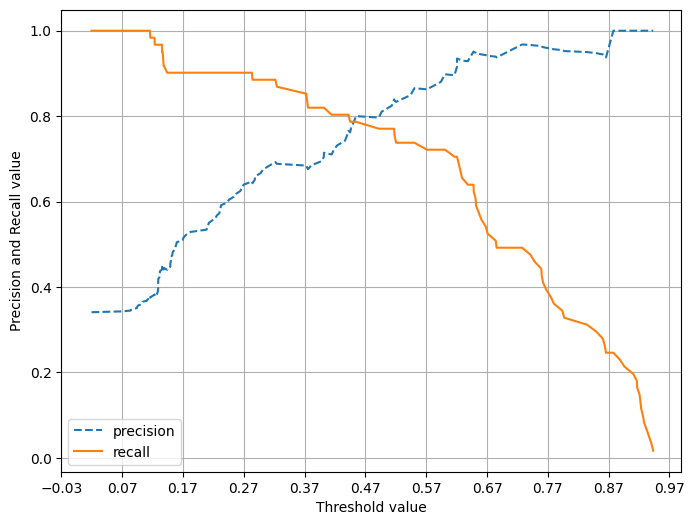

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

def precision_recall_curve_plot(y_test, pred_proba_c1):
  ## threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray를 추출한다
  precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)

  ## X축을 threshold값으로, Y축은 정밀도, 재현율 값으로 각각 Plot을 수행한다. 이 때 정밀도는 점선으로 표시한다
  plt.figure(figsize=(8, 6))
  threshold_boundary = thresholds.shape[0]
  plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
  plt.plot(thresholds, recalls[0:threshold_boundary], label='recall')

  ## threshold 값 X축의 Scale을 0.1 단위로 변경한다
  start, end = plt.xlim()
  plt.xticks(np.round(np.arange(start, end, 0.1), 2))

  ## x축, y축 label과 legend, 그리고 grid을 설정한다
  plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
  plt.legend(); plt.grid()
  plt.show()

precision_recall_curve_plot(y_test, lr_clf.predict_proba(X_test)[:, 1])

# F1 스코어



*   F1 스코어(score)는 정밀도와 재현율을 결합한 지표이다. F1 스코어는 정밀도와 재현율이 어느 한쪽으로 치우치지 않는 수치를 나타낼 때 상대적으로 높은 값을 가진다. (F1) = 2/( (1/recall) + (1/precision) ) = 2(precision * recall)/(precision+recall)
*   사이킷런은 F1 스코어를 구하기 위해 f1_score()라는 API를 제공한다.




In [22]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, pred)
print('F1 스코어: {0:.4f}'.format(f1))

F1 스코어: 0.7966


In [25]:
def get_clf_eval(y_test, pred):
  confusion = confusion_matrix(y_test, pred)
  accuracy = accuracy_score(y_test, pred)
  precision = precision_score(y_test, pred)
  recall = recall_score(y_test, pred)
  ## F1 스코어를 추가한다
  f1 = f1_score(y_test, pred)
  print('오차 행렬')
  print(confusion)
  ## F1 score print를 추가한다
  print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}'.format(accuracy, precision, recall, f1))

thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]
pred_proba = lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test, pred_proba[:, 1].reshape(-1, 1), thresholds)

임곗값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197, F1: 0.7576
임곗값: 0.45
오차 행렬
[[105  13]
 [ 13  48]]
정확도: 0.8547, 정밀도: 0.7869, 재현율: 0.7869, F1: 0.7869
임곗값: 0.5
오차 행렬
[[108  10]
 [ 14  47]]
정확도: 0.8659, 정밀도: 0.8246, 재현율: 0.7705, F1: 0.7966
임곗값: 0.55
오차 행렬
[[111   7]
 [ 16  45]]
정확도: 0.8715, 정밀도: 0.8654, 재현율: 0.7377, F1: 0.7965
임곗값: 0.6
오차 행렬
[[113   5]
 [ 17  44]]
정확도: 0.8771, 정밀도: 0.8980, 재현율: 0.7213, F1: 0.8000


F1 스코어는 임곗값이 0.6일 때 가장 좋은 값을 보였는데, 이 때 재현율이 크게 감소했다.

## ROC 곡선과 AUC



*   ROC 곡선과 이에 기반한 AUC 스코어는 이진 분류의 예측 성능 측정에서 중요하게 사용되는 지표이다. **ROC 곡선(Reciever Operation Characteristic Curve)**은 우리말로 수신자 판단 곡선으로 불린다. 일반적으로 의학 분야에서 많이 사용되나 머신러닝의 이진 분류 모델의 예측 성능을 판단하는 중요한 평가 지표이기도 하다. ROC 곡선은 FPR(Fales Positive Rate)이 변할 때 TPR(True Positive Rate)이 어떻게 변하는지를 나타내는 곡선이다. FPR을 X축으로, TPR을 Y축으로 잡으면 FPR의 변화에 따른 TPR의 변화가 곡선 형태로 나타난다. 이 때 TPR은 재현율(민감도)으로, TP / (FN + TP)의 값이다. 민감도에 대응하는 지표로 TNR(True Negative Rate)이라고 불리는 특이성(Specificity)이 있다. FPR은 FP / (FP + TN)의 값으로, 1 - TNR이다.
*   ROC 곡선에서 가운데 직선은 ROC 곡선의 최저 값으로, 왼쪽 하단과 오른쪽 상단을 대각선으로 이은 것이다. ROC 곡선이 가운데 직선에 가까울수록 성능이 떨어지는 것이며, 멀어질수록 성능이 뛰어난 것이다.
*   ROC 곡선은 FPR을 0부터 1까지 변경하면서 TPR의 변화값을 구한다. FPR을 변화시키는 것은 곧 분류 결정 임곗값을 조정하는 것인데, 분류 결정 임곗값은 Positive 예측값을 결정하는 확률의 기준이기 때문에 FPR을 0으로 만들기 위해서는 임곗값을 1로 지정하면 된다. FPR을 1로 만들기 위해서는 TN을 0으로 만들어야한다. 즉, 임곗값을 0으로 지정한다.
*   사이킷런은 ROC 곡선을 구하기 위해 roc_curve() API를 제공한다. 사용법은 precision_recall_curve() API와 유사하다 단지 반환값이 FPR, TPR, 임곗값으로 구성되어 있다는 점이 다르다. 입력 파라미터는 y_true(실제 클래스값 array), y_score(보통 predict_proba()의 반환 값 array에서 Positive 칼럼의 예측 확률)이며, 반환값은 앞서 말한 바와 같이 array 형태의 fpr, tpr, thresholds이다.





In [28]:
from sklearn.metrics import roc_curve
## 타이타닉 생존자 예측 모델의 FPR, TPR, 임곗값을 구한다

## 레이블 값이 1일 때의 예측 확률을 추출한다
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

fprs, tprs, thresholds = roc_curve(y_test, pred_proba_class1)
## 반환된 임곗값 배열에서 샘플로 데이터를 추출하되, 임곗값을 5 Step으로 추출한다
## thresholds[0]은 max(예측확률)+1로 임의 설정된다. 이를 제외하기 위해 np.arange를 1부터 시작한다
thr_index = np.arange(1, thresholds.shape[0], 5)
print('샘플 추출을 위한 임곗값 배열의 index:', thr_index)
print('샘플 index로 추출한 임곗값: ', np.round(thresholds[thr_index], 2))

## 5 step 단위로 추출된 임곗값에 따른 FPR, TPR 값
print('샘플 임곗값별 FPR: ', np.round(fprs[thr_index], 3))
print('샘플 임곗값별 TPR: ', np.round(tprs[thr_index], 3))

샘플 추출을 위한 임곗값 배열의 index: [ 1  6 11 16 21 26 31 36 41 46]
샘플 index로 추출한 임곗값:  [0.94 0.73 0.62 0.52 0.44 0.28 0.15 0.14 0.13 0.12]
샘플 임곗값별 FPR:  [0.    0.008 0.025 0.076 0.127 0.254 0.576 0.61  0.746 0.847]
샘플 임곗값별 TPR:  [0.016 0.492 0.705 0.738 0.803 0.885 0.902 0.951 0.967 1.   ]


임곗값이 1에 가까운 값에서 점점 작아지면서 FPR이 점점 커지고, FPR이 조금씩 커질 때 TPR은 가파르게 커짐을 알 수 있다.

ConversionError: Failed to convert value(s) to axis units: 'FPR( 1 - Specificity )'

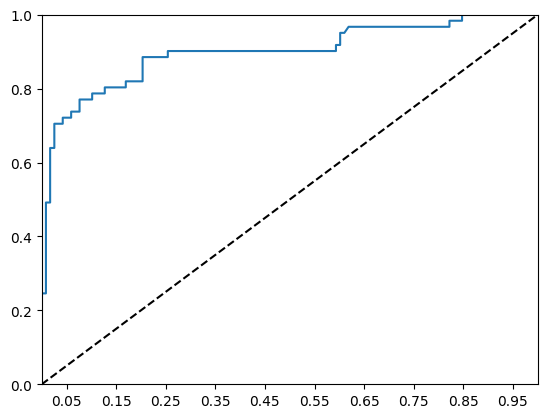

In [29]:
def roc_curve_plot(y_test, pred_proba_c1):
  ## 임곗값에 따른 FPR, TPR 값을 반환받는다
  fprs, tprs, thresholds = roc_curve(y_test, pred_proba_c1)
  ## ROC 곡선을 그래프 곡선으로 그린다
  plt.plot(fprs, tprs, label='ROC')
  ## 가운데 대각선 직선을 그린다
  plt.plot([0, 1], [0, 1], 'k--', label='Random')

  ## FPR X축의 Scale을 0.1 단위로 변경하고, X, Y축명을 설정한다
  start, end = plt.xlim()
  plt.xticks(np.round(np.arange(start, end, 0.1), 2))
  plt.xlim(0, 1); plt.ylim(0, 1)
  plt.xticks('FPR( 1 - Specificity )'); plt.xlabel(' TPR (Recall )')
  plt.legend()

roc_curve_plot(y_test, pred_proba[:, 1])



*   일반적으로 ROC 곡선 자체는 FPR과 TPR의 변화 값을 보는데 이용하며 분류의 성능 지표로 사용되는 것은 ROC 곡선 면적에 기반한 AUC 값으로 결정한다. AUC(Area Under Curve) 값은 ROC 곡선 밑의 면적을 구한 것으로, 일반적으로 1에 가까울수록 좋은 수치이다. AUC 수치가 커지려면 FPR이 작은 상태에서 얼마나 큰 TPR을 얻을 수 있느냐가 관건이다. (i) 가운데 직선에 멀어지고 (ii) 왼쪽 상단 모서리 쪽으로 가파르게 곡선이 이동할수록 직사각형에 가까운 곡선이 되어 면적이 1에 가까워지는 좋은 ROC AUC 성능 수치를 얻게 된다. 보통의 분류는 0.5 이상의 AUC를 가진다.



In [31]:
from sklearn.metrics import roc_auc_score

pred_proba = lr_clf.predict_proba(X_test)[:, 1]
roc_score = roc_auc_score(y_test, pred_proba)
print('ROC AUC 값: {0:.4f}'.format(roc_score))

ROC AUC 값: 0.8987


In [48]:
def get_clf_eval(y_test, pred=None, pred_proba=None):
  confusion = confusion_matrix(y_test, pred)
  accuracy = accuracy_score(y_test, pred)
  precision = precision_score(y_test, pred)
  recall = recall_score(y_test, pred)
  f1 = f1_score(y_test, pred)
  ## ROC-AUC를 추가한다
  roc_auc = roc_auc_score(y_test, pred_proba)
  print('오차 행렬')
  print(confusion)
  ## ROC-AUC print를 추가한다
  print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}, AUC: {4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

## 피마 인디언 당뇨병 예측

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

diabetes_data = pd.read_csv('/content/diabetes.csv')
print(diabetes_data['Outcome'].value_counts())
diabetes_data.head(3)

Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1


In [46]:
diabetes_data.info()  ## feature의 타입과 Null 개수를 살펴본다

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [49]:
## 피처 데이터 세트 X, 레이블 데이터 세트 y를 추출한다
## 맨 끝이 Outcome 칼럼으로 레이블 값이다. 칼럼 위치 -1을 이용해 추출한다
X = diabetes_data.iloc[:, :-1]
y = diabetes_data['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=156, stratify=y)

## 로지스틱 회귀로 학습, 예측 및 평가를 수행한다
lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, pred, pred_proba)

오차 행렬
[[87 13]
 [22 32]]
정확도: 0.7727, 정밀도: 0.7111, 재현율: 0.5926, F1: 0.6465, AUC: 0.8083


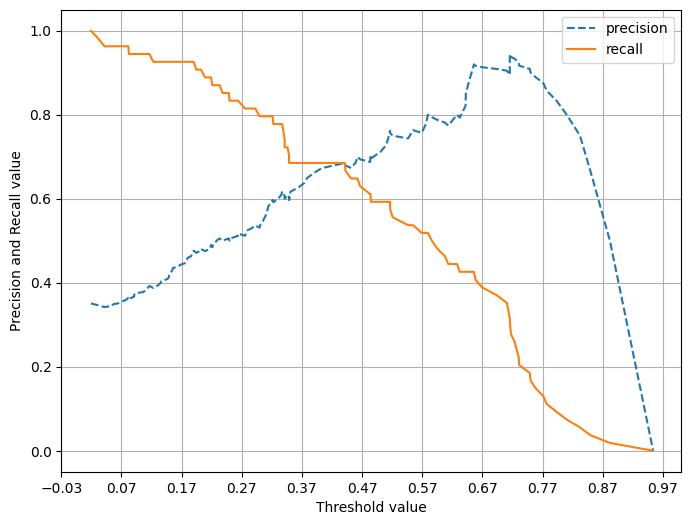

In [50]:
pred_proba_c1 = lr_clf.predict_proba(X_test)[:, 1]
precision_recall_curve_plot(y_test, pred_proba_c1)

재현율 곡선을 보면 임곗값을 0.42 정도로 낮추면 정밀도와 재현율이 어느 정도 균형을 맞출 것 같다. 하지만, 두 개의 지표 모두 0.7이 안 되는 수치로 보인다.

In [51]:
diabetes_data.describe()    ## 다시 데이터를 점검한다

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


min() 값이 0으로 되어 있는 피처가 상당히 많은데, 예를 들어 Glucose 피처의 경우 포도당 수치인데 min 값이 0인 것은 말이 되지 않는다.

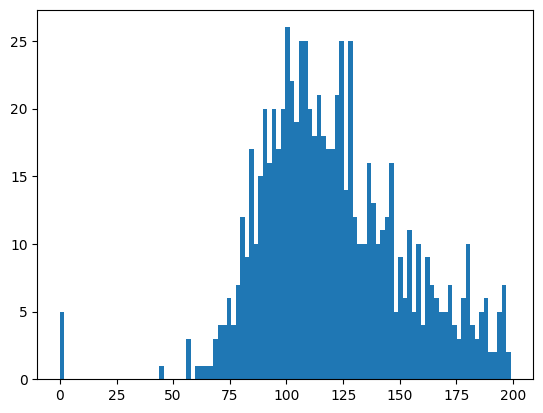

In [53]:
plt.hist(diabetes_data['Glucose'], bins=100)
plt.show()

In [54]:
# 0값을 검사한 피처는 다음과 같다
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

## 전체 데이터 건수는
total_count = diabetes_data['Glucose'].count()

## 0값의 건수 및 전체 데이터 건수 대비 몇 퍼센트 비율로 존재하는지 확인한다
for feature in zero_features:
  zero_count = diabetes_data[diabetes_data[feature] == 0][feature].count()
  print('{0} 0 건수는 {1}, 퍼센트는 {2:.2f} %'.format(feature, zero_count,
                                               100*zero_count/total_count))

Glucose 0 건수는 5, 퍼센트는 0.65 %
BloodPressure 0 건수는 35, 퍼센트는 4.56 %
SkinThickness 0 건수는 227, 퍼센트는 29.56 %
Insulin 0 건수는 374, 퍼센트는 48.70 %
BMI 0 건수는 11, 퍼센트는 1.43 %


In [55]:
## zero_features 리스트 내부에 저장된 개별 피처들에 대해 0값을 평균 값으로 대체한다
mean_zero_features = diabetes_data[zero_features].mean()
diabetes_data[zero_features] = diabetes_data[zero_features].replace(0, mean_zero_features)

In [58]:
X = diabetes_data.iloc[:, :-1]
y = diabetes_data.iloc[:, -1]

## StandardScaler 클래스를 이용해 피처 데이터 세트에 일괄적으로 스케일링을 적용한다
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state =156, stratify=y)

## 로지스틱 회귀로 학습, 예측 및 평가를 수행한다
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
pred = lr_clf.predict(X_test)
pred_proba = lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, pred, pred_proba)

오차 행렬
[[90 10]
 [21 33]]
정확도: 0.7987, 정밀도: 0.7674, 재현율: 0.6111, F1: 0.6804, AUC: 0.8433


In [66]:
thresholds = [0.3, 0.33, 0.36, 0.39, 0.42, 0.45, 0.48, 0.50]
pred_proba = lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test, pred_proba[:,1].reshape(-1, 1), thresholds  )

임곗값: 0.3


InvalidParameterError: The 'y_score' parameter of roc_auc_score must be an array-like. Got None instead.

In [64]:
## 임곗값을 0.48로 변경한 BInarizer을 생성한다
binarizer = Binarizer(threshold=0.48)

## 위에서 구한 lr_clf의 predict_proba() 예측 확률 array에서 1에 해당하는 칼럼값을 Binarizer으로 변환한다
pred_th_048 = binarizer.fit_transform(pred_proba[:, 1].reshape(-1, 1))
get_clf_eval(y_test, pred_th_048, pred_proba[:, 1])

오차 행렬
[[88 12]
 [19 35]]
정확도: 0.7987, 정밀도: 0.7447, 재현율: 0.6481, F1: 0.6931, AUC: 0.8433
